### With the new convergence method that was just developed (torsion, alpha carbon, contact) Frobenius and JSD - retroanalyze if a previously run simulation would have converged.

In [1]:
from FultonMarket.FultonMarketAnalysis import FultonMarketAnalysis

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



jax:    0.7.2
jaxlib: 0.7.2
numpy:  2.3.5
python: 3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 16:05:46) [GCC 13.3.0]
device info: Tesla V100-SXM2-32GB-1, 1 local devices"
process_count: 1
platform: uname_result(system='Linux', node='exp-5-58', release='4.18.0-513.24.1.el8_9.x86_64', version='#1 SMP Thu Apr 4 18:13:02 UTC 2024', machine='x86_64')

$ nvidia-smi
Sat Apr  4 17:52:24 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-SXM2...  On   | 0

In [ ]:
color_map = {'torsion': 'g',
             'alpha_carbon': 'c',
             'contact': 'darkorange'}


def plot_convergence_metric(metric_dict, func='jsd', distype='torsion', history=True):
    """
    where metric_dict came from retro_convergence_report
    where func should be 'jsd' or 'frobenius'
    where distype in 'torsion', 'alpha_carbon', 'contact'
    """
    
    import matplotlib.pyplot as plt
    n_sim_nos = len(metric_dict)
    
    for sim_no, metrics in metric_dict.items():
        #if sim_no % 10 == 0:
        if sim_no == n_sim_nos -1:
            dists = metrics[func][distype]
            if dists:
                x_0, y_0 = sim_no, dists[-1]
                if history:
                    xs, ys = [x_0 - i for i in range(len(dists))], [dist for dist in dists[::-1]]
                    #sizes = [40 * (0.8**i) for i in range(len(dists))]
                    
                    plt.plot([(x+1)/n_sim_nos for x in xs],
                             ys,
                             c=color_map[distype])#s=sizes, )
                plt.scatter((x_0+1)/n_sim_nos, y_0, c=color_map[distype])#s=sizes, )

def add_equil_metric_to_plot(metric_dict):
    n_sim_nos = len(metric_dict)
    sim_nos = [key for key in metric_dict.keys()]
    equil_fractions = [val['equil_fraction'] for key, val in metric_dict.items()]
    colors = ['b' if frac < 0.80 else 'r' for frac in equil_fractions]
    plt.scatter([(sim_no +1)/n_sim_nos for sim_no in sim_nos],
                equil_fractions,
                c=colors, marker='*')

In [ ]:
#Aiman, 5HT2A
simu_direcs = [
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc4_0/',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/J_paper/replica_exchange2/fixed_7wc4_2/',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/J_paper/replica_exchange/fixed_7wc4_1/',
]

tops_filenames = [
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb',
]

archive_directories = [
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_2/',
]

In [ ]:
import os
analyzers = []
matriceses = []
reports = []
metricses = []

for i, (direc_in, pdb_in, cache_dir) in enumerate(zip(simu_direcs, tops_filenames, archive_directories)):
    print('############################################################################')
    print(direc_in)
    print(pdb_in)
    print(cache_dir)
    
    analyzer = FultonMarketAnalysis(input_dir=direc_in,
                                    pdb=pdb_in,
                                    sele_str='resname UNK')
    
    matrices = analyzer.retro_analyze_all(n_resample=1000,
                                          output_cache_dir=cache_dir,
                                          getcontacts_script='/expanse/lustre/projects/uil133/josephdb/getcontacts/get_dynamic_contacts.py',
                                          conda_env='pyinteraph2',
                                          getcontacts_python=os.path.join(os.environ['CONDA_PREFIX'].replace('replica2','pyinteraph2'),'bin','python'))
    report, metrics = analyzer.retro_convergence_report(n_resample=1000, output_cache_dir=cache_dir,
                                                frobenius_thresh=0.01, jsd_thresh=0.10)
    analyzers.append(analyzer)
    matriceses.append(matrices)
    reports.append(report)
    metricses.append(metrics)

In [8]:
simu_direcs = [
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc4_0/',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/J_paper/replica_exchange2/fixed_7wc4_2/',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/J_paper/replica_exchange/fixed_7wc4_1/',
    
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/AM630_0/',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/AM630_1/',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/AM630_2/',
    
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/output/RS1125_0/',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/output/RS1125_1/',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/output/RS1125_2/',
    
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/output/RS1126_0/',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/output/RS1126_1/',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/output/RS1126_2/',
    
    '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/GR89696/0_0/',
    '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/GR89696/0_1/',
    '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/GR89696/0_2/',
    
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/HMR_3.5_Runs/AM630_7ps_mpi/run_01/',
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/HMR_3.5_Runs/AM630_7ps_mpi/run_02/',
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/HMR_3.5_Runs/AM630_7ps_mpi/run_03/',
    
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/Auto_Converge_2.0x1.0/5HT2B_LSD_from_7SRQ/',
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/Auto_Converge_2.0x1.0/5HT2B_LSD_from_7SRR/',
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/Auto_Converge_2.0x1.0/5HT2B_LSD_from_7SRS/',
]

tops_filenames = [
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb',
    
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1125.pdb',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1125.pdb',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1125.pdb',
    
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1126.pdb',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1126.pdb',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1126.pdb',

    '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/GR89696/GR89696/0.pdb',
    '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/GR89696/GR89696/0.pdb',
    '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/GR89696/GR89696/0.pdb',
    
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/MotorRowRuns/5HT2B/restrained_7srq/Step_5.pdb',
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/MotorRowRuns/5HT2B/restrained_7srr/Step_5.pdb',
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/MotorRowRuns/5HT2B/restrained_7srs/Step_5.pdb',
]

archive_directories = [
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_2/',
    
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_2.0x1.0_2/',
    
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1125_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1125_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1125_2.0x1.0_2/',
    
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1126_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1126_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1126_2.0x1.0_2/',
    
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_gr89696_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_gr89696_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_gr89696_2.0x1.0_2/',
    
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_3.5x7.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_3.5x7.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_3.5x7.0_2/',

    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2b_lsd_7srq_2.0x1.0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2b_lsd_7srr_2.0x1.0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2b_lsd_7srs_2.0x1.0/',
]

In [9]:
len(simu_direcs), len(tops_filenames), len(archive_directories)

(21, 21, 21)

In [10]:
for elem in [f"sbatch run_retro.job {direc_in} {pdb_in} --output_cache_dir {cache_dir}"for i, (direc_in, pdb_in, cache_dir) in enumerate(zip(simu_direcs, tops_filenames, archive_directories))]:
    print(elem)

sbatch run_retro.job /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc4_0/ /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb --output_cache_dir /expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_0/
sbatch run_retro.job /expanse/lustre/projects/iit122/akhan3/5HT2A/J_paper/replica_exchange2/fixed_7wc4_2/ /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb --output_cache_dir /expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_1/
sbatch run_retro.job /expanse/lustre/projects/iit122/akhan3/5HT2A/J_paper/replica_exchange/fixed_7wc4_1/ /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb --output_cache_dir /expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_2/
sbatch run_retro.job /expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/AM630_0/ /expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb --output_cache_dir /expanse/lustre/

In [5]:
#This block is a LOT faster if you submit the jobs
import os
analyzers = []
matriceses = []
reports = []
metricses = []

for i, (direc_in, pdb_in, cache_dir) in enumerate(zip(simu_direcs, tops_filenames, archive_directories)):
    print('############################################################################')
    print(direc_in)
    print(pdb_in)
    print(cache_dir)
    
    analyzer = FultonMarketAnalysis(input_dir=direc_in,
                                    pdb=pdb_in,
                                    sele_str='resname UNK')
    
    matrices = analyzer.retro_analyze_all(n_resample=1000,
                                          output_cache_dir=cache_dir,
                                          getcontacts_script='/expanse/lustre/projects/uil133/josephdb/getcontacts/get_dynamic_contacts.py',
                                          conda_env='pyinteraph2',
                                          getcontacts_python=os.path.join(os.environ['CONDA_PREFIX'].replace('replica2','pyinteraph2'),'bin','python'))
    report, metrics = analyzer.retro_convergence_report(n_resample=1000, output_cache_dir=cache_dir,
                                                frobenius_thresh=0.01, jsd_thresh=0.10)
    analyzers.append(analyzer)
    matriceses.append(matrices)
    reports.append(report)
    metricses.append(metrics)

############################################################################
/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc4_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_0/
04/04/2026 17:52:39 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc4_0/saved_variables
04/04/2026 17:52:40 // Ligand selection string: resname UNK
04/04/2026 17:52:42 // Temperature array shapes: [(0, (135,)), (1, (135,)), (2, (135,)), (3, (135,)), (4, (135,)), (5, (135,)), (6, (135,)), (7, (135,)), (8, (135,)), (9, (135,)), (10, (135,)), (11, (135,)), (12, (135,)), (13, (135,)), (14, (135,)), (15, (135,)), (16, (135,)), (17, (135,)), (18, (135,)), (19, (135,)), (20, (135,)), (21, (135,)), (22, (135,)), (23, (135,)), (24, (135,)), (25, (135,)), (26, (135,)), (27, (135,)), (28, (135,)), (29, (135,)), (30, (135,)), (31, (135,)), (32, (


******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************



04/04/2026 17:53:23 // Final energy matrix shape: (9800, 136, 136)
04/04/2026 17:53:23//Mode: cache directory (writes -> /expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_0/)
04/04/2026 17:53:23 // retro_analyze_all: processing 54 sub-simulations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]
04/04/2026 17:53:23 // sim_no=0: all matrices present, skipping
04/04/2026 17:53:24 // sim_no=1: all matrices present, skipping
04/04/2026 17:53:24 // sim_no=2: all matrices present, skipping
04/04/2026 17:53:24 // sim_no=3: all matrices present, skipping
04/04/2026 17:53:24 // sim_no=4: all matrices present, skipping
04/04/2026 17:53:25 // sim_no=5: all matrices present, skipping
04/04/2026 17:53:25 // sim_no=6: all matrices present, skipping
04/04/2026 17:53:25 // sim_no=7: all matrices present, skipping
04/0

FileNotFoundError: [Errno 2] No such file or directory: '/expanse/lustre/projects/uil133/josephdb/SimulationData/Auto_Converge_2.0x1.0/5HT2B_LSD_from_7SRS/saved_variables/8/temperatures.npy'

In [6]:
color_map = {'torsion': 'g',
             'alpha_carbon': 'c',
             'contact': 'darkorange'}


def plot_convergence_metric(metric_dict, func='jsd', distype='torsion', history=True):
    """
    where metric_dict came from retro_convergence_report
    where func should be 'jsd' or 'frobenius'
    where distype in 'torsion', 'alpha_carbon', 'contact'
    """
    
    import matplotlib.pyplot as plt
    n_sim_nos = len(metric_dict)
    
    for sim_no, metrics in metric_dict.items():
        #if sim_no % 10 == 0:
        if sim_no == n_sim_nos -1:
            dists = metrics[func][distype]
            if dists:
                x_0, y_0 = sim_no, dists[-1]
                if history:
                    xs, ys = [x_0 - i for i in range(len(dists))], [dist for dist in dists[::-1]]
                    #sizes = [40 * (0.8**i) for i in range(len(dists))]
                    
                    plt.plot([(x+1)/n_sim_nos for x in xs],
                             ys,
                             c=color_map[distype])#s=sizes, )
                plt.scatter((x_0+1)/n_sim_nos, y_0, c=color_map[distype])#s=sizes, )

def add_equil_metric_to_plot(metric_dict):
    n_sim_nos = len(metric_dict)
    sim_nos = [key for key in metric_dict.keys()]
    equil_fractions = [val['equil_fraction'] for key, val in metric_dict.items()]
    colors = ['b' if frac < 0.80 else 'r' for frac in equil_fractions]
    plt.scatter([(sim_no +1)/n_sim_nos for sim_no in sim_nos],
                equil_fractions,
                c=colors, marker='*')

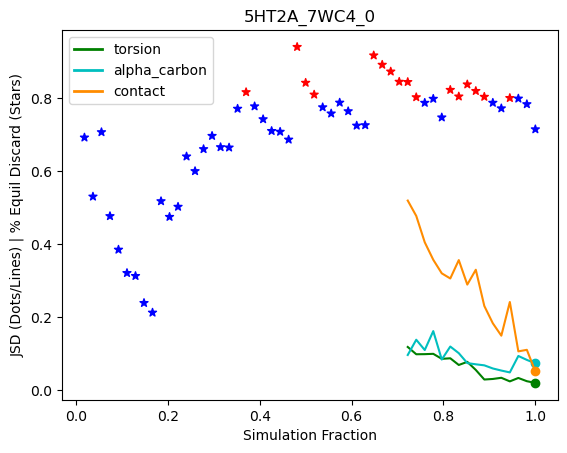

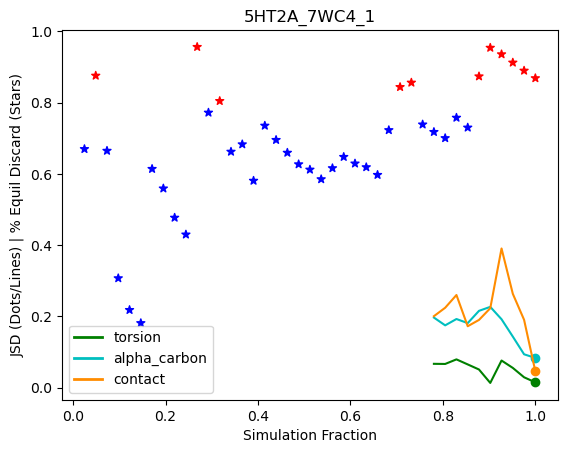

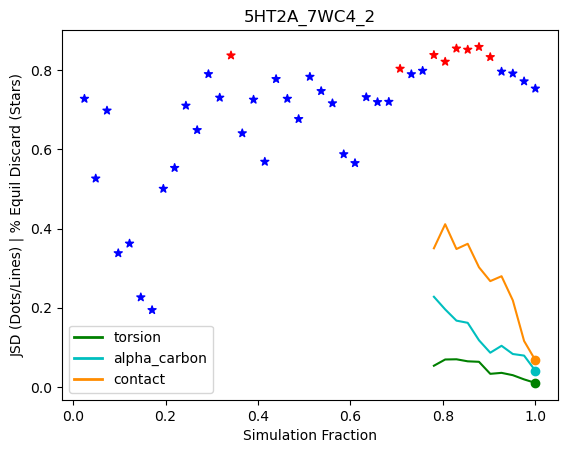

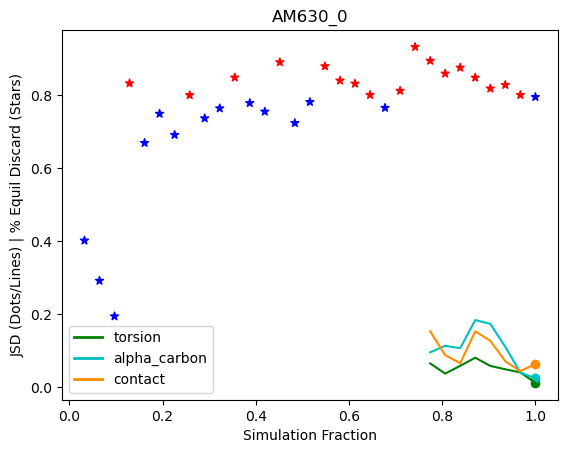

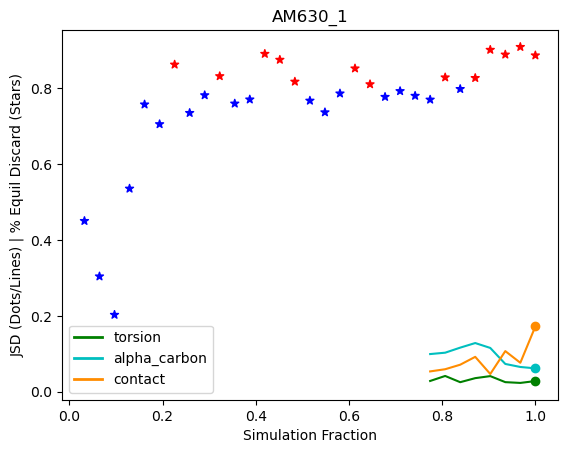

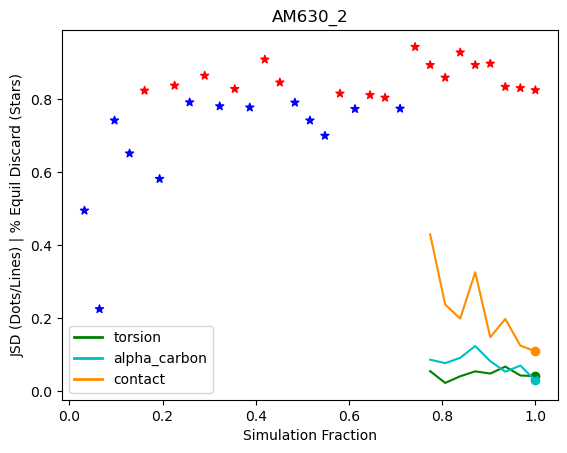

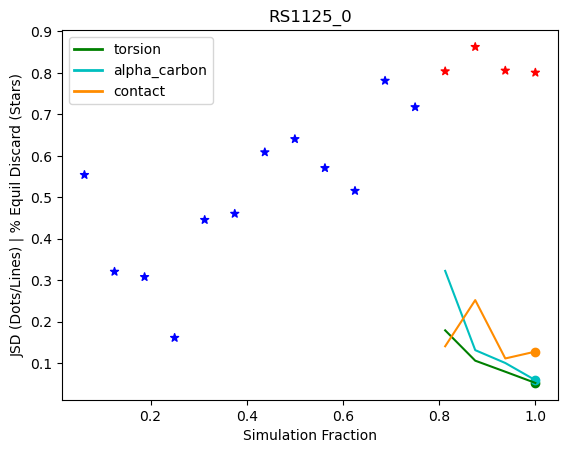

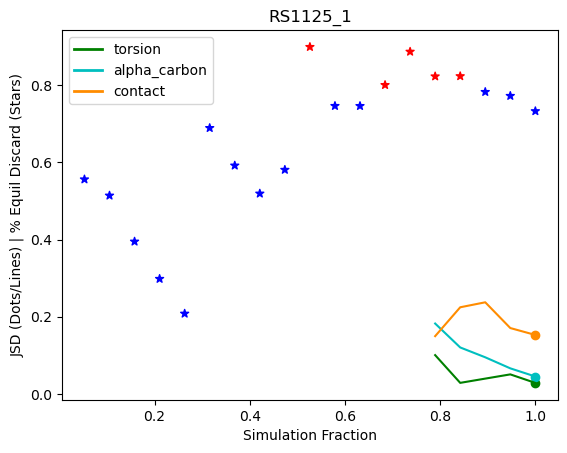

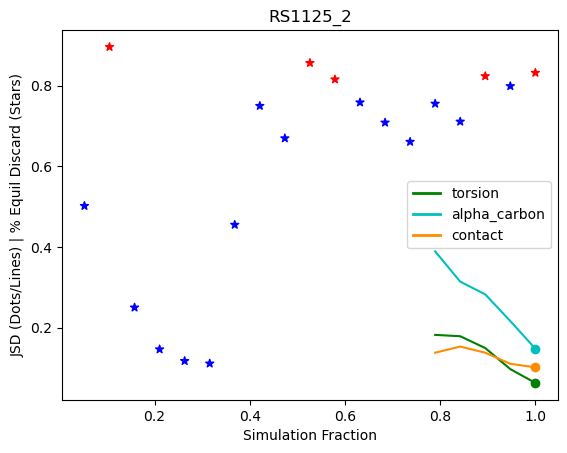

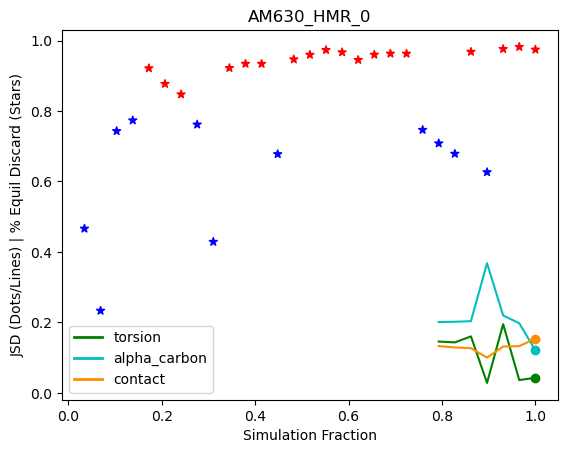

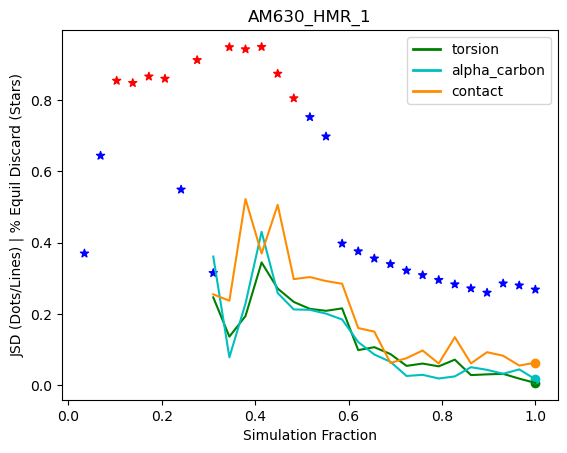

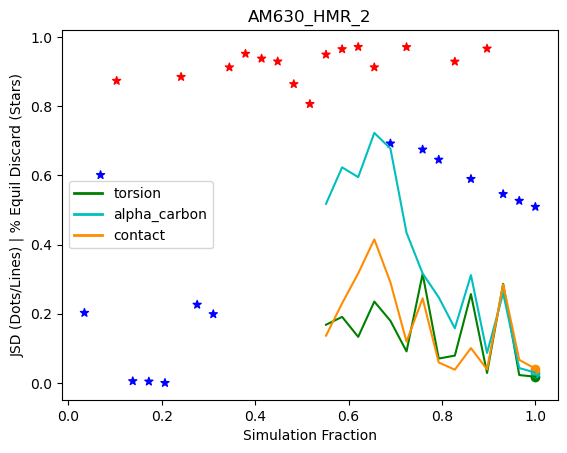

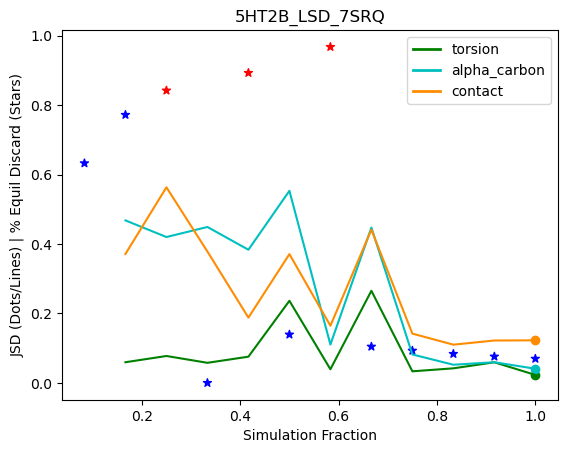

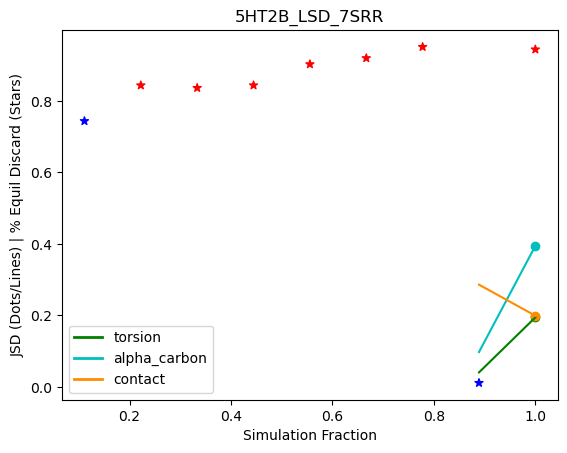

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
titles = ['5HT2A_7WC4_0', '5HT2A_7WC4_1', '5HT2A_7WC4_2',
          'AM630_0', 'AM630_1', 'AM630_2',
          'RS1125_0', 'RS1125_1', 'RS1125_2',
          #'RS1126_0', 'RS1126_1', 'RS1126_2',
          'AM630_HMR_0', 'AM630_HMR_1', 'AM630_HMR_2',
          '5HT2B_LSD_7SRQ', '5HT2B_LSD_7SRR', '5HT2B_LSD_7SRS']

for i, metrics in enumerate(metricses):
    plt.clf()
    history=True
    func='jsd'
    plot_convergence_metric(metrics, func=func, distype='torsion', history=history)
    plot_convergence_metric(metrics, func=func, distype='alpha_carbon', history=history)
    plot_convergence_metric(metrics, func=func, distype='contact', history=history)
    add_equil_metric_to_plot(metrics)
    lines, keys = [Line2D([0], [0], color=color_map[key], lw=2) for key in color_map.keys()], [key for key in color_map.keys()]
    plt.legend(lines, keys)
    plt.xlabel('Simulation Fraction')
    plt.ylabel('JSD (Dots/Lines) | % Equil Discard (Stars)')
    plt.title(titles[i])
    plt.show()